# 04 - End-to-end field analysis

This notebook demonstrates the M3 end-to-end cycle on one microscope-field-style image:

`field image -> YOLO26n WBC detections -> crops -> DinoBloom-B + MLP 18-class predictions -> uncertainty decisions -> structured JSON`.

It is research-only. The goal is to make each intermediate output visible: bundle metadata, selected image, raw detections, annotated boxes, confidence heatmap, crops, all 18 probabilities, review decisions, timing, and final insights.

## 1. Environment and assets

Install notebook-only visualization dependencies if needed, import the project, and verify required model bundles.

In [18]:
!pip install -q ultralytics matplotlib pandas seaborn Pillow timm


In [19]:
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Rectangle
from PIL import Image
from ultralytics import YOLO

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src' / 'bloodfilm').exists():
    REPO_ROOT = next(path for path in Path.cwd().resolve().parents if (path / 'src' / 'bloodfilm').exists())
sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)
print('Working directory:', Path.cwd())

from bloodfilm.classification.inference import classify_crop
from bloodfilm.classification.bundle import inspect_bundle, load_bundle_documents
from bloodfilm.classification.png import write_rgb_png
from bloodfilm.config import load_config
from bloodfilm.detection.sweep import run_prediction_sweep
from bloodfilm.documents import load_config_document, write_json

DETECTOR_PROFILE_CONFIG = Path('configs/inference_dense_field_recall_v0_1.yaml')
DETECTOR_PROFILE = load_config(DETECTOR_PROFILE_CONFIG)
SELECTED_DETECTOR_EXPERIMENT = DETECTOR_PROFILE.detector_profile or 'dense_field_recall_v0.1'
DETECTOR_WEIGHTS = Path('outputs/detector_multidomain/wbc-detector-multidomain-yolo26n-a/weights/best.pt')
DETECTOR_EVALUATION = Path('outputs/reports/detector_leukemia_test_only.json')
LEGACY_DETECTOR_BUNDLE = Path('models/txl-pbc-yolo26n-v0.1')
CLASSIFIER_BUNDLE = Path('models/mll23-dinobloom-b-mlp-v0.1')
BACKBONE_WEIGHTS = Path('models/backbones/dinobloom-b.pth')
OUTPUT_DIR = Path('outputs/e2e')
CROP_DIR = OUTPUT_DIR / 'crops'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CROP_DIR.mkdir(parents=True, exist_ok=True)

for path in [DETECTOR_PROFILE_CONFIG, DETECTOR_WEIGHTS, DETECTOR_EVALUATION, LEGACY_DETECTOR_BUNDLE, CLASSIFIER_BUNDLE, BACKBONE_WEIGHTS]:
    assert path.exists(), f'Missing required asset: {path}'

print('Selected detector profile:', SELECTED_DETECTOR_EXPERIMENT)
print('Detector profile config:', DETECTOR_PROFILE_CONFIG)
print('Detector weights:', DETECTOR_WEIGHTS)
print('Detector evaluation:', DETECTOR_EVALUATION)
print('Legacy threshold bundle:', LEGACY_DETECTOR_BUNDLE)
print('Classifier bundle:', CLASSIFIER_BUNDLE)
CLASSIFIER_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Backbone weights:', BACKBONE_WEIGHTS)
print('Classifier device:', CLASSIFIER_DEVICE)




Working directory: /home/ash/Desktop/projects/blood
Selected detector profile: dense_field_recall_v0.1
Detector profile config: configs/inference_dense_field_recall_v0_1.yaml
Detector weights: outputs/detector_multidomain/wbc-detector-multidomain-yolo26n-a/weights/best.pt
Detector evaluation: outputs/reports/detector_leukemia_test_only.json
Legacy threshold bundle: models/txl-pbc-yolo26n-v0.1
Classifier bundle: models/mll23-dinobloom-b-mlp-v0.1
Backbone weights: models/backbones/dinobloom-b.pth
Classifier device: cpu


In [3]:
detector_evaluation = load_config_document(DETECTOR_EVALUATION)
detector_thresholds = load_config_document(LEGACY_DETECTOR_BUNDLE / 'thresholds.json')
classifier_inspection = inspect_bundle(CLASSIFIER_BUNDLE)
classifier_docs = load_bundle_documents(CLASSIFIER_BUNDLE)

selected_detector_eval = next(
    item for item in detector_evaluation['evaluations']
    if item.get('experiment') == 'A_finetune_txl_pbc'
)
selected_detector_metrics = selected_detector_eval['metrics']
display(pd.DataFrame([
    {'asset': 'detector', 'status': detector_evaluation['status'], 'version': SELECTED_DETECTOR_EXPERIMENT, 'recall': selected_detector_metrics['metrics/recall(B)'], 'mAP50': selected_detector_metrics['metrics/mAP50(B)'], 'mAP50-95': selected_detector_metrics['metrics/mAP50-95(B)']},
    {'asset': 'classifier', 'status': classifier_inspection['status'], 'version': classifier_docs['bundle']['name'], 'recall': None, 'mAP50': None, 'mAP50-95': None},
]))
print('Frozen dense-field detector settings:', json.dumps({
    'detector_profile': SELECTED_DETECTOR_EXPERIMENT,
    'confidence_threshold': DETECTOR_PROFILE.detector.confidence_threshold,
    'iou_threshold': DETECTOR_PROFILE.detector.iou_threshold,
    'tiling_enabled': DETECTOR_PROFILE.tiling.enabled,
    'tile_size': DETECTOR_PROFILE.tiling.tile_size,
    'overlap_ratio': DETECTOR_PROFILE.tiling.overlap_ratio,
    'tile_core_ownership': DETECTOR_PROFILE.tiling.tile_core_ownership,
    'containment_deduplication': DETECTOR_PROFILE.tiling.containment_deduplication,
}, indent=2))
print('Legacy detector thresholds, retained for reference only:', json.dumps(detector_thresholds['selected'], indent=2))


,asset,status,version,recall,mAP50,mAP50-95
0,detector,ok,dense_field_recall_v0.1,0.933,0.925,0.546
1,classifier,ok,mll23-dinobloom-b-mlp-v0.1,NaN,NaN,NaN


Frozen dense-field detector settings: {
  "detector_profile": "dense_field_recall_v0.1",
  "confidence_threshold": 0.15,
  "iou_threshold": 0.6,
  "tiling_enabled": true,
  "tile_size": 384,
  "overlap_ratio": 0.2,
  "tile_core_ownership": true,
  "containment_deduplication": true
}
Legacy detector thresholds, retained for reference only: {
  "confidence_threshold": 0.25,
  "false_positives_per_image": 0.001,
  "iou_threshold": 0.5,
  "precision": 0.999,
  "recall": 1.0,
  "selection_reason": "default_threshold_meets_high_recall_on_test_summary"
}


## 2. Select one field image

Set `SAMPLE_FIELD=/path/to/image` to use a specific microscope field. If not set, the notebook uses the first TXL-PBC test image so the detector path can be exercised immediately.

Selected field: /home/ash/Desktop/projects/blood/data/microscope_samples/wbc8.jpg
Image size: (389, 514)


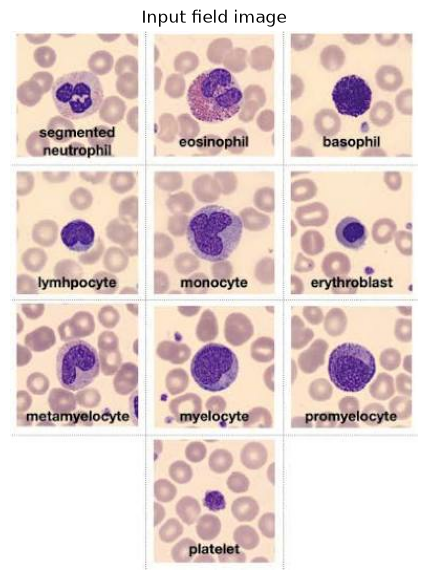

In [20]:
SAMPLE_FIELD='/home/ash/Desktop/projects/blood/data/microscope_samples/wbc8.jpg'
sample_override = globals().get('SAMPLE_FIELD') or os.environ.get('SAMPLE_FIELD')
if sample_override:
    FIELD_IMAGE = Path(sample_override)
else:
    candidates = sorted(Path('data/detection/txl-pbc-wbc-yolo/images/test').glob('*'))
    if not candidates:
        candidates = sorted(Path('data/raw/TXL-PBC/TXL-PBC/images/test').glob('*'))
    assert candidates, 'No sample image found. Run detector prepare-yolo or set SAMPLE_FIELD.'
    FIELD_IMAGE = candidates[0]

image = Image.open(FIELD_IMAGE).convert('RGB')
print('Selected field:', FIELD_IMAGE)
print('Image size:', image.size)
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.title('Input field image')
plt.axis('off');

## 3. Load detector and classifier

The detector uses the frozen provisional `dense_field_recall_v0.1` profile: field-ROI tiled inference with 384 px tiles, 20% overlap, confidence 0.15, global IoU 0.60, tile-core ownership, containment/center deduplication, and box-sanity review flags. This profile is frozen pending ground-truth evaluation; do not continue tuning thresholds from visual counts alone. The classifier path uses the frozen MLL23 DinoBloom-B MLP bundle and emits all 18 probabilities per crop.


In [21]:
detector_weights = DETECTOR_WEIGHTS
confidence_threshold = float(DETECTOR_PROFILE.detector.confidence_threshold or 0.15)
iou_threshold = float(DETECTOR_PROFILE.detector.iou_threshold or 0.60)
tile_size = DETECTOR_PROFILE.tiling.tile_size
overlap_ratio = DETECTOR_PROFILE.tiling.overlap_ratio
preprocessing_mode = 'field_roi_tiled' if DETECTOR_PROFILE.tiling.enabled else 'field_roi'
# Keep a direct YOLO handle visible for notebook users, but use the shared sweep path below
# so tile-core ownership, containment deduplication, and review flags match the CLI.
detector = YOLO(str(detector_weights))
print('Loaded YOLO detector:', detector_weights)
print('Detector profile:', SELECTED_DETECTOR_EXPERIMENT)
print('Mode:', preprocessing_mode)
print('Confidence threshold:', confidence_threshold, 'IoU threshold:', iou_threshold)
print('Tile size:', tile_size, 'Overlap ratio:', overlap_ratio)
print('Classifier version:', classifier_docs['bundle']['name'])


Loaded YOLO detector: outputs/detector_multidomain/wbc-detector-multidomain-yolo26n-a/weights/best.pt
Detector profile: dense_field_recall_v0.1
Mode: field_roi_tiled
Confidence threshold: 0.15 IoU threshold: 0.6
Tile size: 384 Overlap ratio: 0.2
Classifier version: mll23-dinobloom-b-mlp-v0.1


## 4. Detect WBC candidates

Run the frozen dense-field detector profile once through the same sweep implementation used by the CLI. This keeps the notebook aligned with tile-core ownership, containment/center deduplication, and localization-review flags. Zero detections are reported explicitly and are not interpreted as a zero differential.


In [22]:
started = time.perf_counter()
detector_report = run_prediction_sweep(
    detector_weights,
    [FIELD_IMAGE],
    [confidence_threshold],
    iou_threshold=iou_threshold,
    image_size=640,
    preprocessing_mode=preprocessing_mode,
    tile_size=tile_size,
    overlap_ratio=overlap_ratio,
)
detector_latency_ms = round((time.perf_counter() - started) * 1000, 3)
detector_candidate = detector_report['candidates'][0]
raw_boxes = detector_candidate['boxes_by_image'][FIELD_IMAGE.stem]
quality_flags = detector_candidate.get('box_quality_flags_by_image', {}).get(FIELD_IMAGE.stem, [[] for _ in raw_boxes])
detections = []
for index, (box, flags) in enumerate(zip(raw_boxes, quality_flags)):
    box_status = box.get('box_status', 'review' if flags else 'accepted')
    box_review_reasons = box.get('box_review_reasons', ['localization_quality'] if flags else [])
    detections.append({
        'index': index,
        'x1': float(box['x1']),
        'y1': float(box['y1']),
        'x2': float(box['x2']),
        'y2': float(box['y2']),
        'score': float(box['score']),
        'box_status': box_status,
        'box_review_reasons': box_review_reasons,
        'box_quality_flags': flags,
    })

detections_df = pd.DataFrame(detections)
print('Detector latency ms:', detector_latency_ms)
print('Detected cells:', len(detections))
print('Box status counts:', detections_df['box_status'].value_counts().to_dict() if not detections_df.empty else {})
print('Detector stage counts:', detector_candidate['counts_by_image'][FIELD_IMAGE.stem])
display(detections_df)


Detector latency ms: 4512.853
Detected cells: 12
Box status counts: {'accepted': 10, 'review': 2}
Detector stage counts: {'tile_count': 4, 'raw_yolo_proposals_count': 39, 'post_confidence_count': 39, 'post_tile_core_count': 12, 'post_tile_merge_count': 12, 'post_global_nms_count': 12, 'post_global_dedup_count': 12, 'post_box_sanity_count': 12, 'maximum_detection_limit_applied': False, 'sent_to_classifier_count': 12, 'box_review_count': 2}


,index,x1,y1,x2,y2,score,box_status,box_review_reasons,box_quality_flags
0,0,167.196106,163.609131,222.412781,221.632919,0.806824,accepted,[],[]
1,1,167.657349,33.254555,223.227524,89.573532,0.805723,accepted,[],[]
2,2,301.072693,294.333603,351.212250,346.747040,0.799157,accepted,[],[]
3,3,170.736420,294.914230,220.061813,345.683167,0.786628,accepted,[],[]
4,4,304.472687,39.507732,346.795502,83.252914,0.785854,accepted,[],[]
5,5,38.176567,36.020473,90.195946,86.404724,0.784467,accepted,[],[]
6,6,42.147976,292.532913,87.031631,344.293900,0.783209,accepted,[],[]
7,7,46.023964,176.620346,83.038368,212.410812,0.701651,accepted,[],[]
8,8,308.063324,174.545029,342.592468,209.922180,0.489022,accepted,[],[]
9,9,181.677567,435.430878,208.065781,460.399353,0.391605,accepted,[],[]


## 5. Visualize boxes and heatmaps

The first panel shows detector boxes and confidence labels. Accepted localization boxes are green. Localization-review boxes are red and must remain review regardless of classifier confidence. The second panel is a detector-confidence heatmap created by adding each box score over its covered pixels; it is a visual explanation, not a saliency map.


Saved overlay: outputs/e2e/field_detector_overlay.png


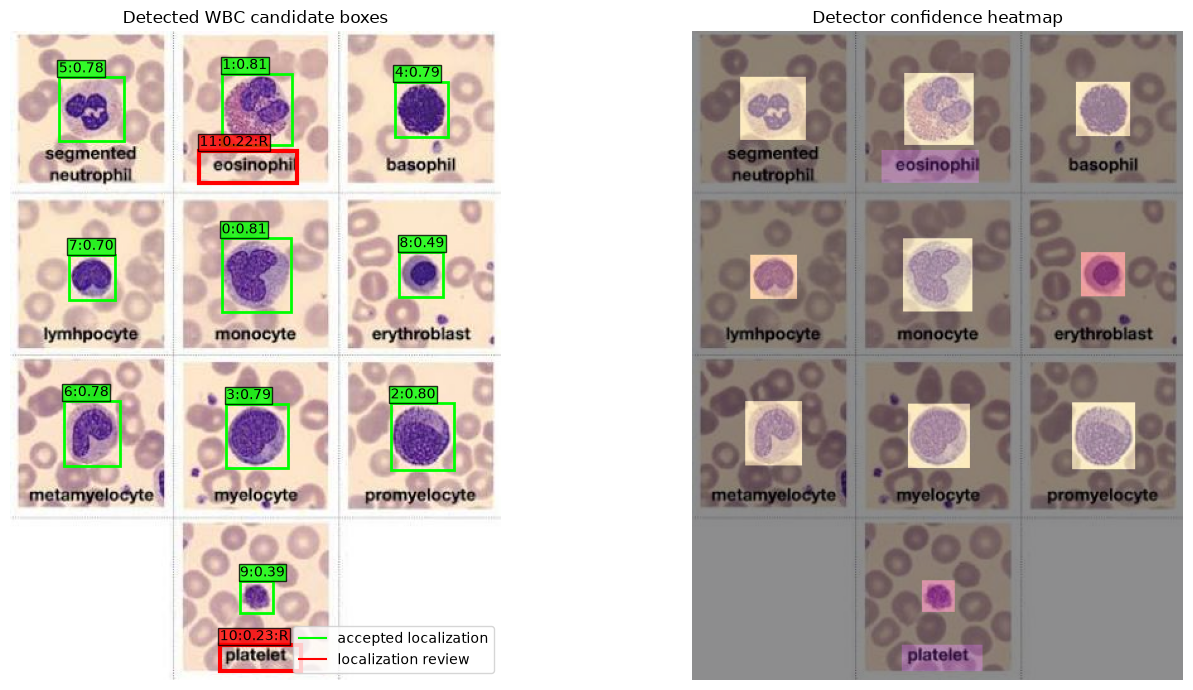

In [23]:
image_array = np.array(image)
heatmap = np.zeros(image_array.shape[:2], dtype=float)
for row in detections:
    x1, y1, x2, y2 = [int(round(row[key])) for key in ['x1', 'y1', 'x2', 'y2']]
    heatmap[max(0, y1):min(image_array.shape[0], y2), max(0, x1):min(image_array.shape[1], x2)] += row['score']
if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(image_array)
axes[0].set_title('Detected WBC candidate boxes')
for row in detections:
    color = 'red' if row['box_status'] == 'review' else 'lime'
    linewidth = 3 if row['box_status'] == 'review' else 2
    rect = Rectangle((row['x1'], row['y1']), row['x2'] - row['x1'], row['y2'] - row['y1'], fill=False, color=color, linewidth=linewidth)
    axes[0].add_patch(rect)
    label = f"{row['index']}:{row['score']:.2f}" + (':R' if row['box_status'] == 'review' else '')
    axes[0].text(row['x1'], max(0, row['y1'] - 4), label, color='black', bbox={'facecolor': color, 'alpha': 0.8, 'pad': 1})
axes[0].plot([], [], color='lime', label='accepted localization')
axes[0].plot([], [], color='red', label='localization review')
axes[0].legend(loc='lower right')
axes[0].axis('off')

axes[1].imshow(image_array)
axes[1].imshow(heatmap, cmap='magma', alpha=0.45)
axes[1].set_title('Detector confidence heatmap')
axes[1].axis('off')
plt.tight_layout()
annotated_path = OUTPUT_DIR / 'field_detector_overlay.png'
fig.savefig(annotated_path, dpi=150)
print('Saved overlay:', annotated_path)


## 6. Crop and classify detected cells

Each detector box is expanded by a small padding ratio, saved as a crop, then passed through the MLL23 classifier. Every cell record keeps detector box status, detector confidence, crop box, predicted class, uncertainty decision, and all 18 probabilities. A localization-review box may still be classified for information, but its final `classification_status` and `decision_status` remain `review` regardless of classifier confidence.


In [16]:
def expanded_box(row, width, height, padding_ratio=0.10):
    box_w = row['x2'] - row['x1']
    box_h = row['y2'] - row['y1']
    return {
        'x1': max(0, int(row['x1'] - box_w * padding_ratio)),
        'y1': max(0, int(row['y1'] - box_h * padding_ratio)),
        'x2': min(width, int(row['x2'] + box_w * padding_ratio)),
        'y2': min(height, int(row['y2'] + box_h * padding_ratio)),
    }

cells = []
classification_started = time.perf_counter()
for row in detections:
    crop_box = expanded_box(row, image.width, image.height)
    cell_id = f"{FIELD_IMAGE.stem}_d{row['index']:04d}"
    crop = image.crop((crop_box['x1'], crop_box['y1'], crop_box['x2'], crop_box['y2']))
    crop_path = CROP_DIR / f'{cell_id}.png'
    crop.save(crop_path)
    prediction = classify_crop(bundle_dir=CLASSIFIER_BUNDLE, image_path=crop_path, backbone_weights=BACKBONE_WEIGHTS, device=CLASSIFIER_DEVICE)
    probabilities = prediction['probabilities']
    assert len(probabilities) == 18, 'Expected all 18 probabilities'
    decision = prediction['decision']
    box_status = row.get('box_status', 'accepted')
    box_review_reasons = list(row.get('box_review_reasons', []))
    classifier_status = decision.get('status')
    classification_status = 'review' if box_status == 'review' else classifier_status
    uncertainty_reasons = list(decision.get('uncertainty_reasons', []))
    if box_status == 'review' and 'localization_quality' not in uncertainty_reasons:
        uncertainty_reasons.append('localization_quality')
    cells.append({
        'cell_id': cell_id,
        'box': {key: round(row[key], 3) for key in ['x1', 'y1', 'x2', 'y2']},
        'box_status': box_status,
        'box_review_reasons': box_review_reasons,
        'box_quality_flags': list(row.get('box_quality_flags', [])),
        'crop_box': crop_box,
        'detector_confidence': row['score'],
        'crop_path': str(crop_path),
        'predicted_class': decision.get('label'),
        'classification_confidence': decision.get('confidence'),
        'classifier_status': classifier_status,
        'classification_status': classification_status,
        'decision_status': classification_status,
        'uncertainty_reasons': uncertainty_reasons,
        'probabilities': probabilities,
        'detector_version': SELECTED_DETECTOR_EXPERIMENT,
        'classifier_version': classifier_docs['bundle']['name'],
    })
classification_latency_ms = round((time.perf_counter() - classification_started) * 1000, 3)
print('Classification latency ms:', classification_latency_ms)
print('Cells classified:', len(cells))


Classification latency ms: 73018.657
Cells classified: 12


,cell_id,detector_confidence,box_status,box_review_reasons,predicted_class,classification_confidence,classifier_status,classification_status,decision_status,uncertainty_reasons,crop_path
0,wbc8_d0000,0.806824,accepted,,NaN,0.341173,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0000.png
1,wbc8_d0001,0.805723,accepted,,NaN,0.309991,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0001.png
2,wbc8_d0002,0.799157,accepted,,NaN,0.160963,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0002.png
3,wbc8_d0003,0.786628,accepted,,NaN,0.227661,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0003.png
4,wbc8_d0004,0.785854,accepted,,NaN,0.264099,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0004.png
5,wbc8_d0005,0.784467,accepted,,NaN,0.318408,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0005.png
6,wbc8_d0006,0.783209,accepted,,NaN,0.153285,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0006.png
7,wbc8_d0007,0.701651,accepted,,NaN,0.114857,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0007.png
8,wbc8_d0008,0.489022,accepted,,normoblast,0.672822,review_required,review_required,review_required,,outputs/e2e/crops/wbc8_d0008.png
9,wbc8_d0009,0.391605,accepted,,NaN,0.139021,unknown,unknown,unknown,,outputs/e2e/crops/wbc8_d0009.png


,basophil,eosinophil,neutrophil_band,neutrophil_segmented,monocyte,lymphocyte_typical,lymphocyte_reactive,lymphocyte_large_granular,lymphocyte_neoplastic_other,hairy_cell,plasma_cell,smudge_cell,myeloblast,promyelocyte,promyelocyte_atypical,myelocyte,metamyelocyte,normoblast
wbc8_d0000,0.024391,0.042864,0.108521,0.063577,0.341173,0.019697,0.028747,0.029408,0.027635,0.014592,0.007766,0.036617,0.014798,0.029697,0.111081,0.016367,0.038317,0.044752
wbc8_d0001,0.032507,0.309991,0.028358,0.062266,0.055449,0.025816,0.008152,0.029332,0.015068,0.041979,0.001954,0.061744,0.168638,0.026698,0.087235,0.019648,0.005987,0.019178
wbc8_d0002,0.024466,0.067603,0.040256,0.066163,0.034109,0.015806,0.019358,0.036639,0.028620,0.040642,0.010677,0.028091,0.059387,0.084887,0.160963,0.145333,0.033248,0.103753
wbc8_d0003,0.031131,0.034545,0.050625,0.061761,0.103302,0.013536,0.025951,0.083726,0.025324,0.022860,0.013962,0.032368,0.020222,0.049404,0.227661,0.058807,0.034373,0.110444
wbc8_d0004,0.264099,0.222172,0.021917,0.011889,0.012089,0.069207,0.018279,0.058659,0.023763,0.016581,0.015290,0.043407,0.064636,0.036255,0.005060,0.048794,0.045088,0.022816
wbc8_d0005,0.016564,0.318408,0.034895,0.026548,0.016122,0.014027,0.019560,0.007904,0.019478,0.045202,0.023716,0.036094,0.029294,0.134260,0.083714,0.083425,0.039893,0.050896
wbc8_d0006,0.035165,0.084288,0.153285,0.096261,0.117898,0.013925,0.039052,0.032294,0.028516,0.012144,0.014966,0.045666,0.017803,0.059562,0.045013,0.022141,0.049931,0.132091
wbc8_d0007,0.025932,0.082816,0.033576,0.041194,0.100799,0.082513,0.048736,0.076960,0.036738,0.015437,0.028536,0.082253,0.051540,0.042741,0.081602,0.029857,0.023912,0.114857
wbc8_d0008,0.018071,0.020277,0.006462,0.075474,0.006345,0.010073,0.009820,0.001722,0.003194,0.035271,0.020942,0.010079,0.010050,0.023839,0.049677,0.014460,0.011422,0.672822
wbc8_d0009,0.062681,0.139021,0.017608,0.023354,0.034421,0.028247,0.043624,0.019262,0.025554,0.006205,0.070383,0.099534,0.128774,0.076937,0.068116,0.054349,0.027886,0.074046


Saved probability heatmap: outputs/e2e/classifier_probability_heatmap.png


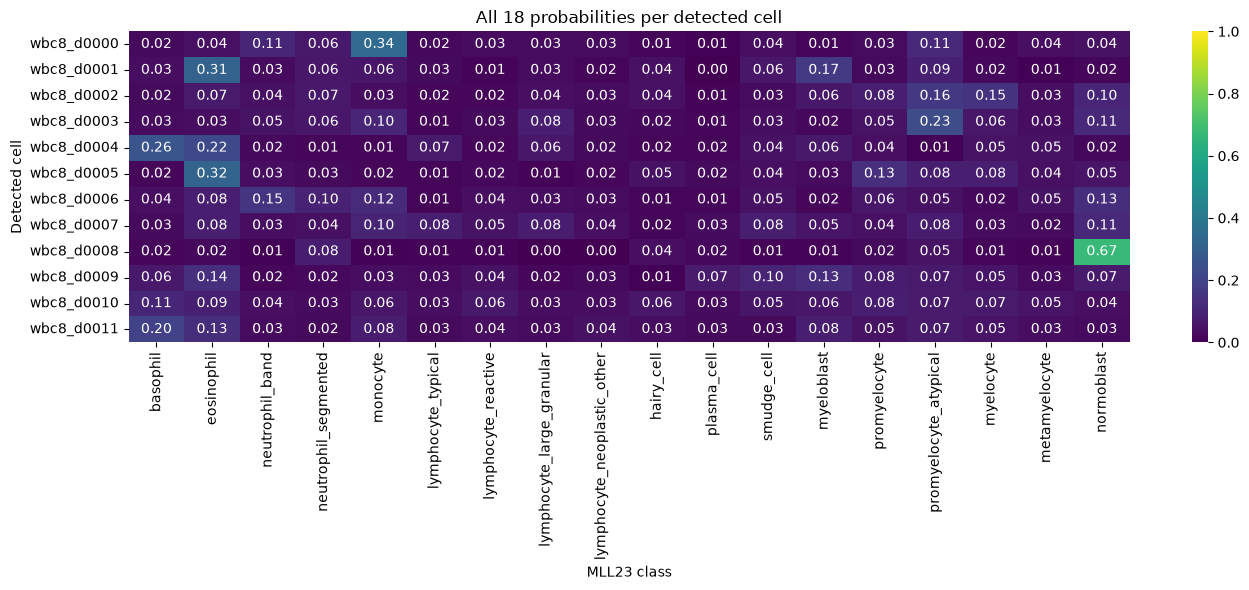

In [24]:
summary_rows = []
for cell in cells:
    summary_rows.append({
        'cell_id': cell['cell_id'],
        'detector_confidence': cell['detector_confidence'],
        'box_status': cell['box_status'],
        'box_review_reasons': ', '.join(cell['box_review_reasons']),
        'predicted_class': cell['predicted_class'],
        'classification_confidence': cell['classification_confidence'],
        'classifier_status': cell['classifier_status'],
        'classification_status': cell['classification_status'],
        'decision_status': cell['decision_status'],
        'uncertainty_reasons': ', '.join(cell['uncertainty_reasons']),
        'crop_path': cell['crop_path'],
    })
cell_df = pd.DataFrame(summary_rows)
display(cell_df)

if cells:
    probability_df = pd.DataFrame({
        cell['cell_id']: {row['class_code']: row['probability'] for row in cell['probabilities']}
        for cell in cells
    }).T
    display(probability_df)
    plt.figure(figsize=(14, max(3, 0.5 * len(probability_df))))
    sns.heatmap(probability_df, cmap='viridis', vmin=0, vmax=1, annot=True, fmt='.2f')
    plt.title('All 18 probabilities per detected cell')
    plt.xlabel('MLL23 class')
    plt.ylabel('Detected cell')
    probability_heatmap = OUTPUT_DIR / 'classifier_probability_heatmap.png'
    plt.tight_layout()
    plt.savefig(probability_heatmap, dpi=150)
    print('Saved probability heatmap:', probability_heatmap)


## 7. Insights and export

Summarize review burden, zero-detection cases, class distribution, latencies, detector stage counts, and saved outputs. The primary JSON artifact is `outputs/e2e/field_analysis.json`, which can be compared across images and future detector/classifier versions. The detector profile is frozen pending ground-truth evaluation; the next gate is full `wbc6` annotation and formal precision/recall analysis, not more threshold or tile sweeps.


In [ ]:
status_counts = cell_df['decision_status'].value_counts().to_dict() if not cell_df.empty else {}
box_status_counts = cell_df['box_status'].value_counts().to_dict() if not cell_df.empty else {}
class_counts = cell_df['predicted_class'].value_counts().to_dict() if not cell_df.empty else {}
record = {
    'schema_version': 1,
    'research_only': True,
    'status': 'zero_detections' if not cells else 'succeeded',
    'source_image': str(FIELD_IMAGE),
    'image_width': image.width,
    'image_height': image.height,
    'detector_version': SELECTED_DETECTOR_EXPERIMENT,
    'detector_profile_config': str(DETECTOR_PROFILE_CONFIG),
    'detector_settings': {
        'preprocessing_mode': preprocessing_mode,
        'confidence_threshold': confidence_threshold,
        'iou_threshold': iou_threshold,
        'tile_size': tile_size,
        'overlap_ratio': overlap_ratio,
        'tile_core_ownership': DETECTOR_PROFILE.tiling.tile_core_ownership,
        'containment_deduplication': DETECTOR_PROFILE.tiling.containment_deduplication,
    },
    'detector_stage_counts': detector_candidate['counts_by_image'][FIELD_IMAGE.stem],
    'classifier_version': classifier_docs['bundle']['name'],
    'detector_latency_ms': detector_latency_ms,
    'classification_latency_ms': classification_latency_ms,
    'cell_count': len(cells),
    'box_status_counts': box_status_counts,
    'decision_status_counts': status_counts,
    'predicted_class_counts': class_counts,
    'missed_cell_rate': None,
    'cells': cells,
    'artifacts': {
        'detector_overlay': str(annotated_path),
        'classifier_probability_heatmap': str(OUTPUT_DIR / 'classifier_probability_heatmap.png'),
    },
    'insights': [
        'Zero detections are reported explicitly and are not treated as a zero differential.',
        'Localization-review boxes force classification_status and decision_status to review regardless of classifier confidence.',
        'dense_field_recall_v0.1 is frozen pending ground-truth evaluation; annotate wbc6 before further detector tuning.',
        'TXL-PBC/LeukemiaAttri detector finds WBC candidates; detailed morphology is assigned by the MLL23 classifier.',
    ],
}
output_json = OUTPUT_DIR / 'field_analysis.json'
write_json(output_json, record)
print('Saved structured E2E JSON:', output_json)
print(json.dumps({
    'status': record['status'],
    'cell_count': record['cell_count'],
    'box_status_counts': box_status_counts,
    'decision_status_counts': status_counts,
    'predicted_class_counts': class_counts,
    'detector_latency_ms': detector_latency_ms,
    'classification_latency_ms': classification_latency_ms,
}, indent=2))
